<a href="https://colab.research.google.com/github/jmora420-hue/Ciencia_de_datos/blob/main/CIENCIA_DATOS_Medidas_centrales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Trabajando con medidas centrales
###1. Trabajando con dataframes
###2. Overview de los datos
###3. Obteniendo medidas centrales
###4. Analizando gráficas

## 1. Trabajando con dataframes

In [1]:
!pip install statsmodels

In [2]:
!pip install wquantiles

In [ ]:
#!pip install git+https://github.com/statsmodels/statsmodels

In [3]:
import pandas as pd
import numpy as np
from scipy.stats import trim_mean
from statsmodels import robust
import wquantiles
import seaborn as sns
import matplotlib.pyplot as plt

In [7]:
estado=pd.read_csv("/content/sample_data/state.csv")

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
#Ver los primeros 5 datos
estado.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [11]:
estado.tail(3)

,State,Population,Murder.Rate,Abbreviation
47,West Virginia,1852994,4.0,WV
48,Wisconsin,5686986,2.9,WI
49,Wyoming,563626,2.7,WY


In [12]:
estado.sample(7)

,State,Population,Murder.Rate,Abbreviation
35,Oklahoma,3751351,4.5,OK
34,Ohio,11536504,4.0,OH
49,Wyoming,563626,2.7,WY
32,North Carolina,9535483,5.1,NC
13,Indiana,6483802,5.0,IN
37,Pennsylvania,12702379,4.8,PA
42,Texas,25145561,4.4,TX


### Overview de la data
Analizando las columnas presentes en el dataframe

In [13]:
estado.columns

Index(['State', 'Population', 'Murder.Rate', 'Abbreviation'], dtype='object')

In [14]:
list(estado.columns)#Convertir en lista el nombre de las columnas

['State', 'Population', 'Murder.Rate', 'Abbreviation']

In [15]:
estado.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   State         50 non-null     object 
 1   Population    50 non-null     int64  
 2   Murder.Rate   50 non-null     float64
 3   Abbreviation  50 non-null     object 
dtypes: float64(1), int64(1), object(2)
memory usage: 1.7+ KB


In [16]:
estado.describe()

,Population,Murder.Rate
count,5.000000e+01,50.000000
mean,6.162876e+06,4.066000
std,6.848235e+06,1.915736
min,5.636260e+05,0.900000
25%,1.833004e+06,2.425000
50%,4.436370e+06,4.000000
75%,6.680312e+06,5.550000
max,3.725396e+07,10.300000


##2. Estimando las tasas de población y asesinatos

In [17]:
estado["Population"].mean()

np.float64(6162876.3)

In [18]:
trim_mean(estado.Population,0.1) #quiero contar el 10% de los datos

np.float64(4783697.125)

In [19]:
estado.Population.median()

4436369.5

In [20]:
estado["Murder.Rate"].mean()

np.float64(4.066)

In [21]:
#Media ponderada de asesinatos
np.average(estado["Murder.Rate"],weights=estado.Population)

np.float64(4.445833981123393)

In [22]:
#Mediana ponderada de asesinatos
wquantiles.median(estado.Population,weights=estado.Population)

np.float64(9660802.03629772)

<Axes: >

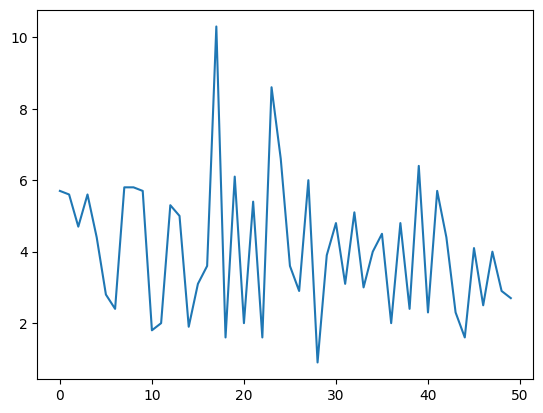

In [23]:
estado["Murder.Rate"].plot.line()

<Axes: >

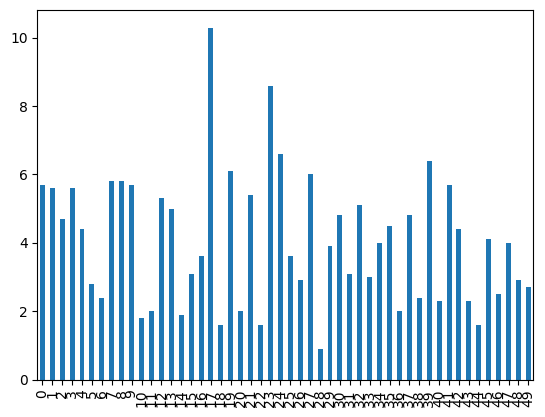

In [24]:
estado["Murder.Rate"].plot.bar()

<Axes: >

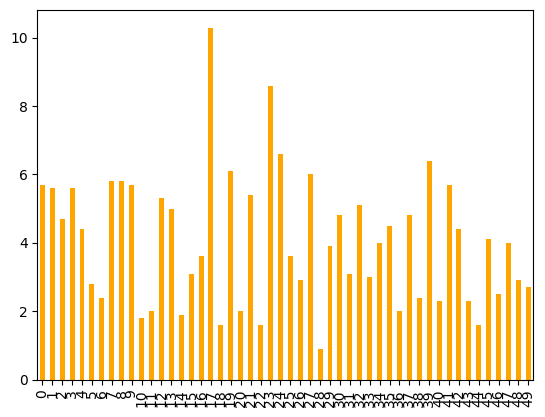

In [25]:
estado["Murder.Rate"].plot.bar(color="orange")

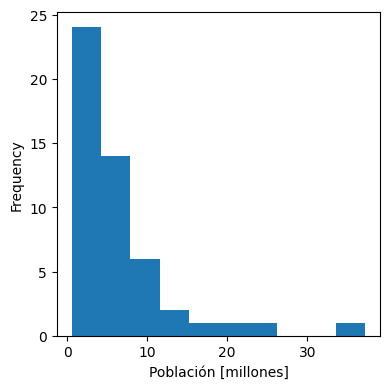

In [26]:
ax=(estado.Population/1_000_000).plot.hist(figsize=(4,4))
ax.set_xlabel("Población [millones]")

plt.tight_layout()
plt.show()

In [27]:
estado.columns

Index(['State', 'Population', 'Murder.Rate', 'Abbreviation'], dtype='object')

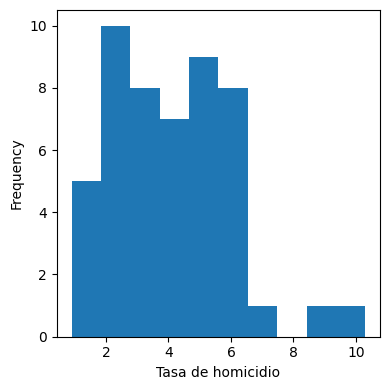

In [28]:
ax=(estado["Murder.Rate"]).plot.hist(figsize=(4,4))
ax.set_xlabel("Tasa de homicidio")

plt.tight_layout()
plt.show()

/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  func(*plot_args, **plot_kwargs)
/usr/local/lib/python3.13/dist-packages/seaborn/distributions.py:2496: UserWarning: Dataset has 0 variance; skipping density estimate. Pass `warn_singular=False` to disable this warning.
  kdeplot(**{axis: a}, ax=ax, color=kde_color, **kde_kws)
/usr/local/lib/python3.13/dist-packages/seaborn/axisgrid.py:854: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an 

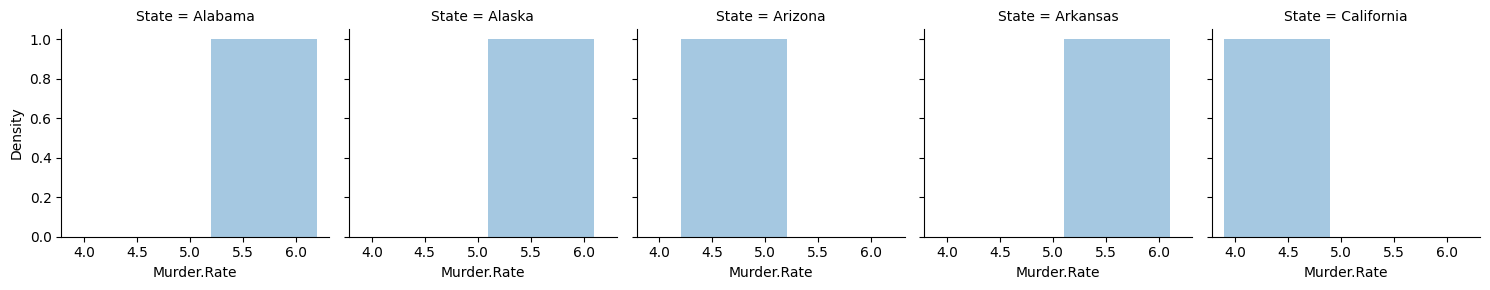

In [30]:
analisis=estado.head()
g=sns.FacetGrid(analisis,col="State")
g.map(sns.distplot,"Murder.Rate")

### TAREA IMPRIMIR DE 5 EN 5

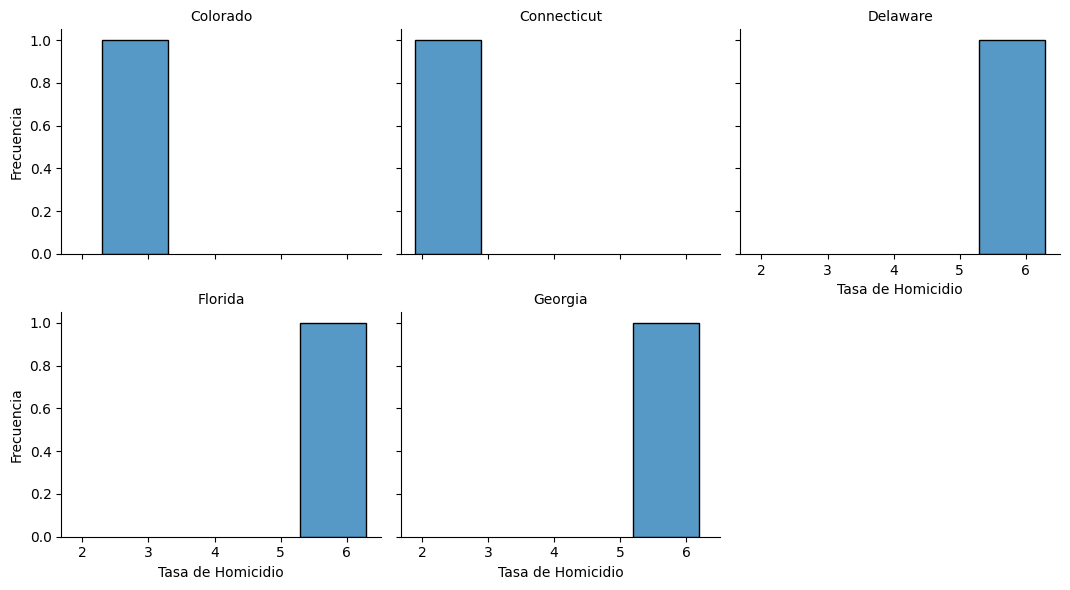

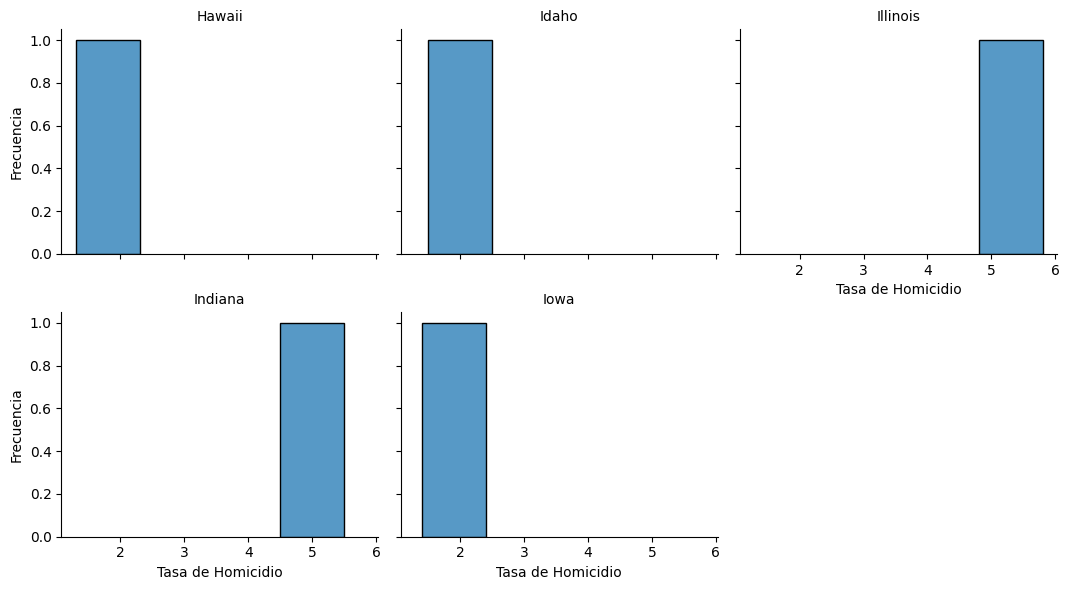

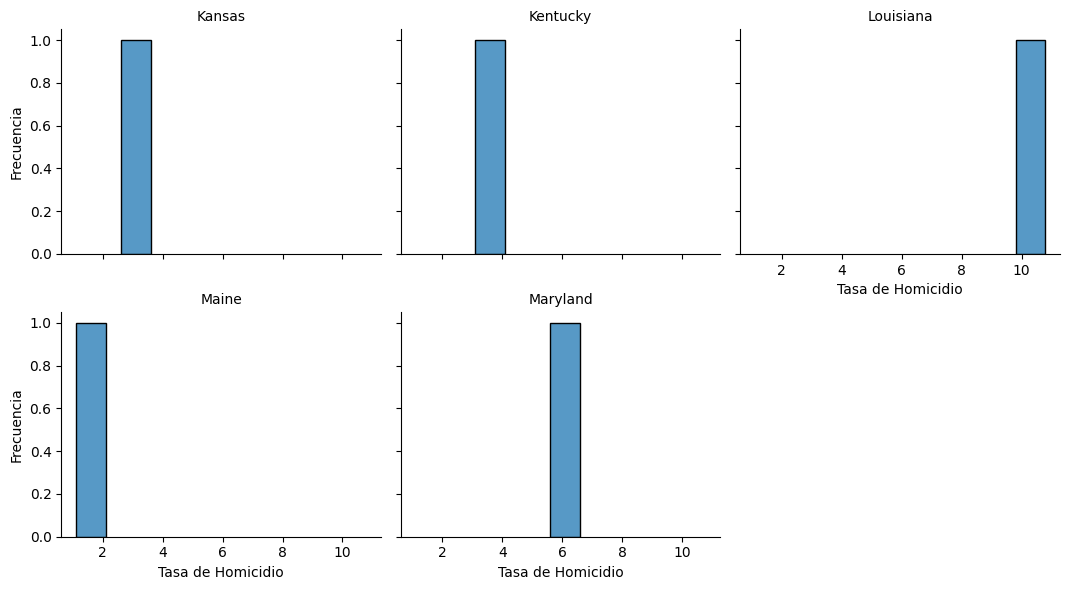

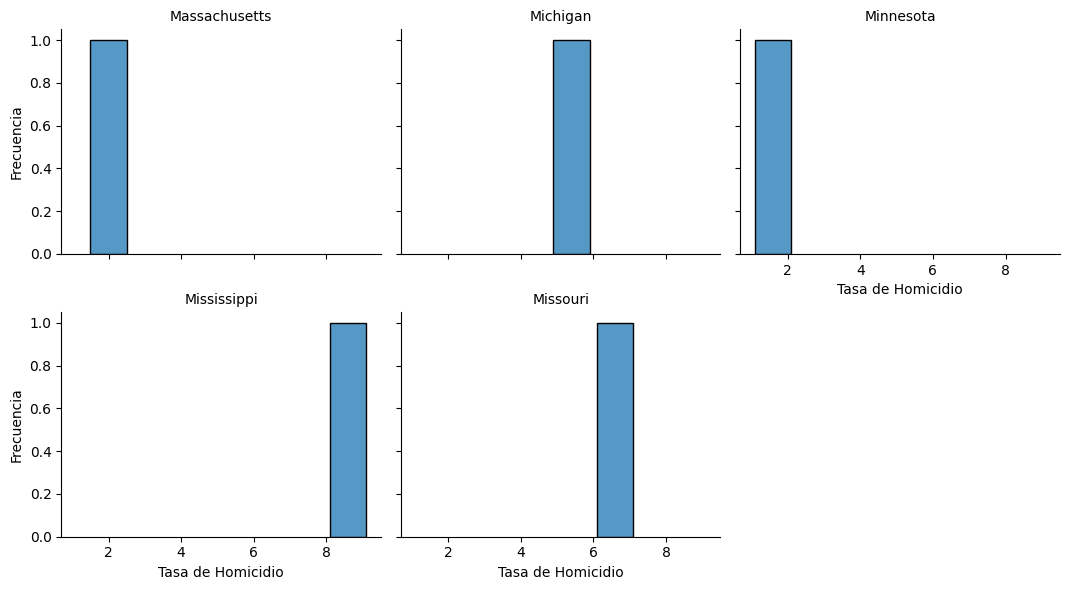

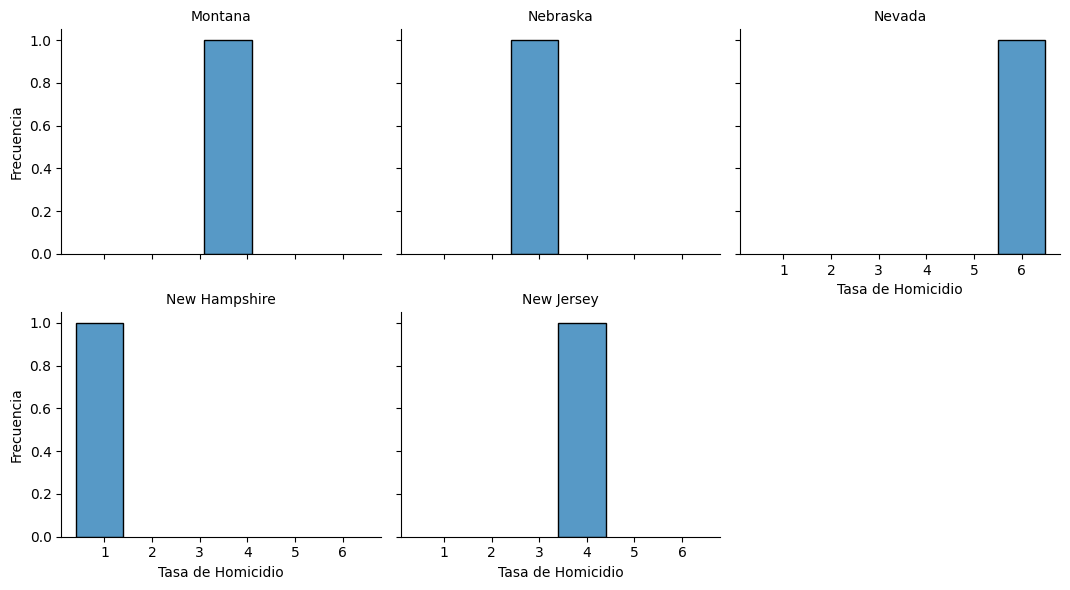

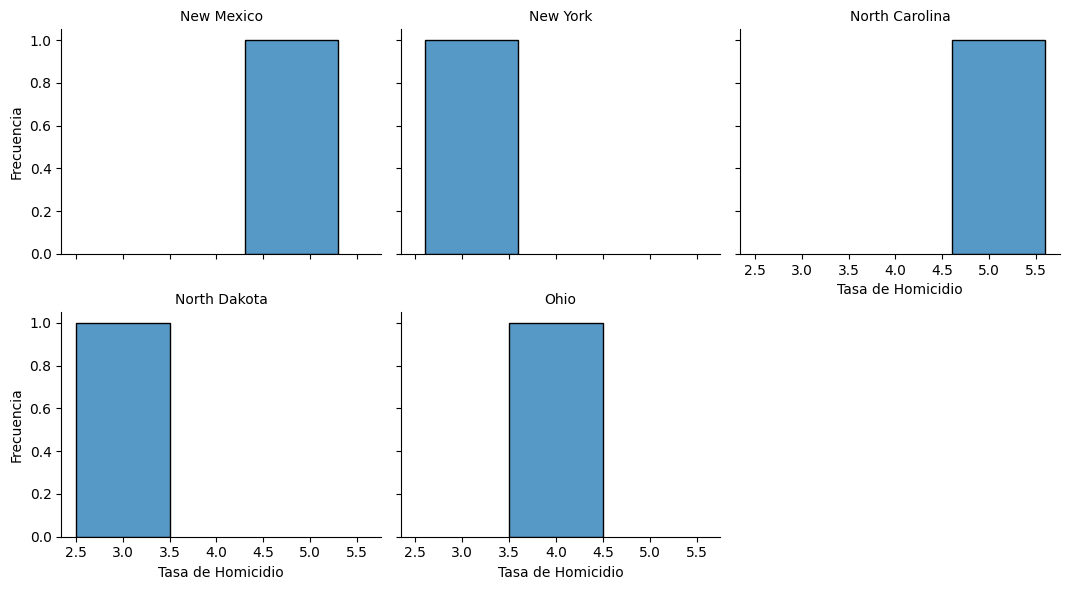

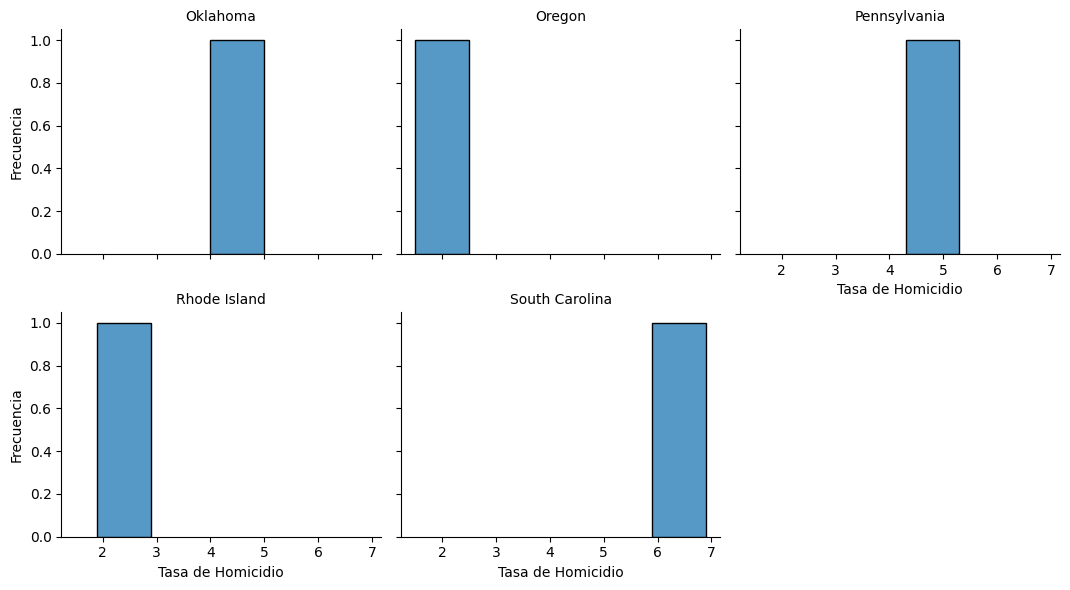

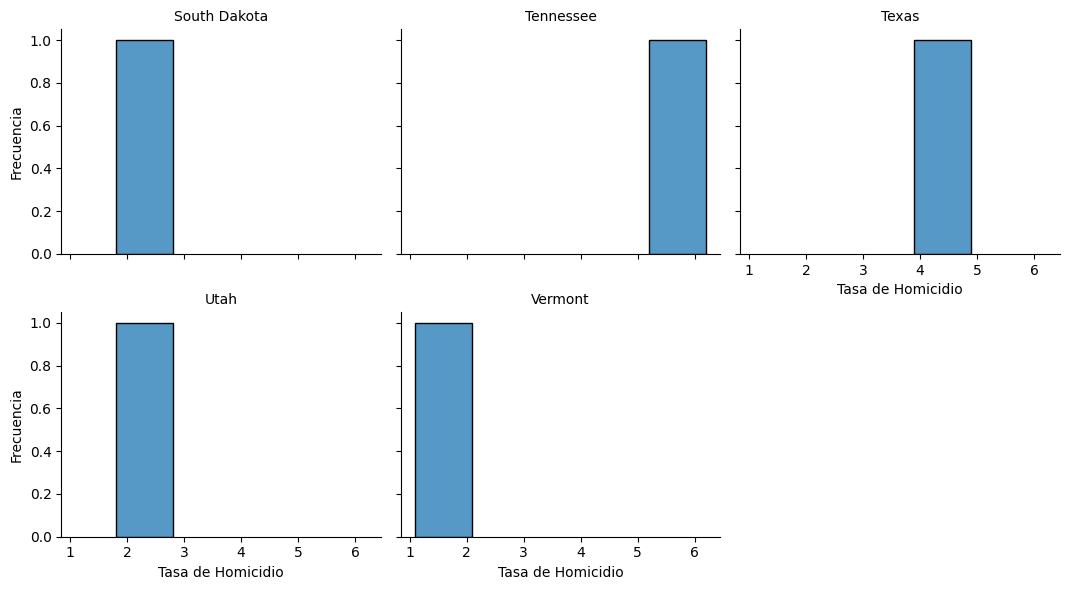

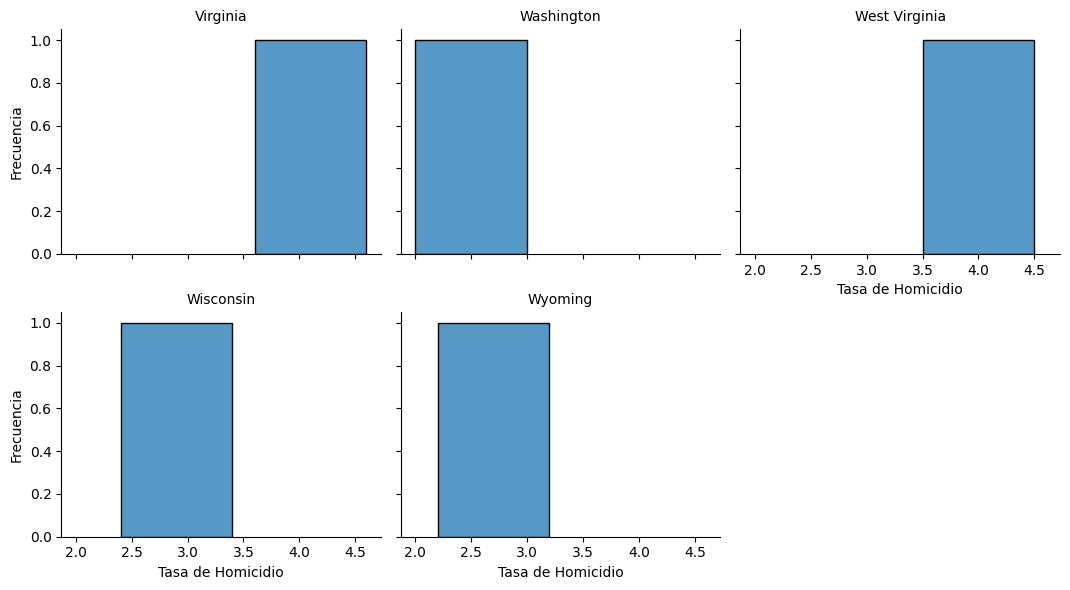

In [49]:
num_states = len(estado)
chunk_size = 5

# Se inicia desde el 6to, osea número 5
for i in range(5, num_states, chunk_size):
    current_chunk = estado.iloc[i : i + chunk_size]


    if current_chunk.empty:
        break

    # Obtiene los nombres de los estados en este fragmento para el título
    first_state = current_chunk['State'].iloc[0]
    last_state = current_chunk['State'].iloc[-1]

    # Crea el FacetGrid y mapea el histograma
    g = sns.FacetGrid(current_chunk, col='State', col_wrap=3, height=3, aspect=1.2)
    g.map(sns.histplot, 'Murder.Rate')
    g.set_axis_labels('Tasa de Homicidio', 'Frecuencia')
    g.set_titles(col_template='{col_name}') # Muestra el nombre del estado en cada subtítulo
    plt.show()

#ESTIMACIÓN DE LA VARIABILIDAD
Mide el grado de agrupación o dispersión de los valores de los datos.

##Términos claves de métricas de variabilidad


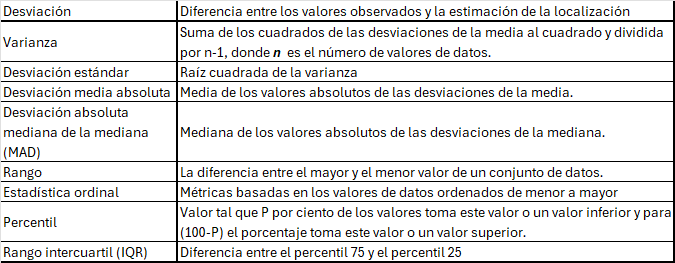

In [35]:
#Consiguiendo el dataset directamente desde google drive. Para ello,
#se debe dar permisos a colab de ingresar a google drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Para este caso, se cargarán los datos desde google drive, por lo cual aconsejo crear una carpeta en Colab Notebooks en donde se ubicarán los datasets de trabajo. En mi caso, mi carpeta se llama ciencia de datos.

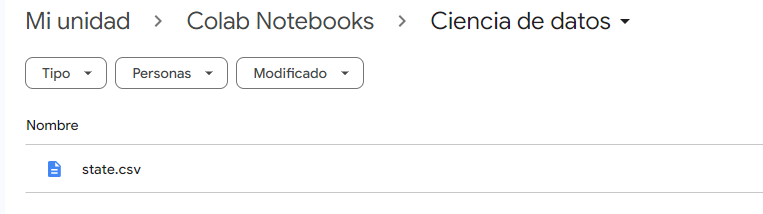

Una vez realizada la activación de google drive, se debe ubicar la carpeta y copiar la ubicación del dataset
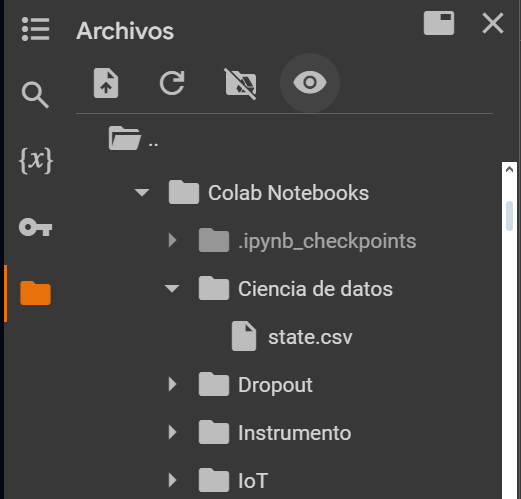

In [36]:
data=pd.read_csv("/content/drive/MyDrive/Colab Notebooks/Ciencia de datos/state.csv")

In [37]:
data.head()

,State,Population,Murder.Rate,Abbreviation
0,Alabama,4779736,5.7,AL
1,Alaska,710231,5.6,AK
2,Arizona,6392017,4.7,AZ
3,Arkansas,2915918,5.6,AR
4,California,37253956,4.4,CA


In [38]:
Mayor_Poblacion = data.groupby(["Population"])["State"].max()
print(Mayor_Poblacion)

Population
563626             Wyoming
625741             Vermont
672591        North Dakota
710231              Alaska
814180        South Dakota
897934            Delaware
989415             Montana
1052567       Rhode Island
1316470      New Hampshire
1328361              Maine
1360301             Hawaii
1567582              Idaho
1826341           Nebraska
1852994      West Virginia
2059179         New Mexico
2700551             Nevada
2763885               Utah
2853118             Kansas
2915918           Arkansas
2967297        Mississippi
3046355               Iowa
3574097        Connecticut
3751351           Oklahoma
3831074             Oregon
4339367           Kentucky
4533372          Louisiana
4625364     South Carolina
4779736            Alabama
5029196           Colorado
5303925          Minnesota
5686986          Wisconsin
5773552           Maryland
5988927           Missouri
6346105          Tennessee
6392017            Arizona
6483802            Indiana
6547629      Mass

In [39]:
#Generando cálculos de desviación estándar y cuantiles
data["Population"].std()

6848235.347401142

In [40]:
#Calculando IQR
data.Population.quantile(0.75)-data.Population.quantile(0.25)

np.float64(4847308.0)

In [41]:
robust.scale.mad(data["Population"])

np.float64(3849876.1459979336)

La desviación estándar es casi dos veces mayor que la MAD (*desviación absoluta mediana de la mediana*).

In [42]:
# Crear un DataFrame de muestra
import pandas as pd

data1 = {'Nombre': ['Juan', 'Alex', 'Pedro'],
        'Edad': [25, 24, 28],
        'Departamento': ['IT', 'RRHH', 'Marketing']}

df = pd.DataFrame(data1)

# Renombrar las columnas 'Edad' y 'Departamento'
df = df.rename(columns={'Edad': 'Años', 'Departamento': 'Depto'})

# Imprimir el DataFrame
print(df)

  Nombre  Años      Depto
0   Juan    25         IT
1   Alex    24       RRHH
2  Pedro    28  Marketing


In [43]:
df.columns

Index(['Nombre', 'Años', 'Depto'], dtype='object')

#EXPLORACIÓN EN LA DISTRIBUCIÓN DE DATOS

En este apartado se explorará:
###1. Diagrama de caja: Visibilización rápida de la distribución de datos.
###2. Diagrama de frecuencias: Registro de recuento de valores de datos numéricos que caen en un conjunto de intervalos.
###3. Histograma: Diagrama de la tabla de frecuencias con los intervalos en el eje x y el recuento (o proporción) en el eje y.
###4. Diagrama de densidad: Versión suavizada del histograma. A menudo basada en una **estimación de la densidad del núcleo (kernel density estimate**).

In [44]:
#Calculando percentiles de la tasa de homicidios por estado
data["Murder.Rate"].quantile([0.05, 0.25, 0.5, 0.75, 0.95])

,Murder.Rate
0.05,1.600
0.25,2.425
0.50,4.000
0.75,5.550
0.95,6.510


Text(0, 0.5, 'Población en millones')

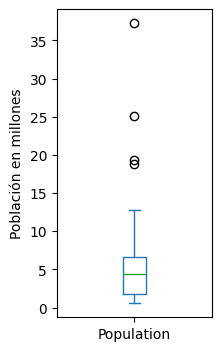

In [45]:
#Dibujando diagramas de caja
ax = (data.Population/1_000_000).plot.box(figsize=(2,4))
ax.set_ylabel("Población en millones")

**TAREA**
El diagrama de cajas y bigotes sirve para poder interpretar de manera gráfica la mediana y la distribución de los datos según su desviación. En este ejemplo, el diagrama grafica la población en los 51 estados y se interpreta observando que la línea verde central representa la mediana, lo cual indica que la mitad de los estados tienen una población aproximada de cuatro a cinco millones de habitantes o menos. Asimismo, el cuerpo azul de la caja ilustra el cincuenta por ciento central de la muestra, demostrando que el grueso de los estados concentra su población entre los dos y los siete millones de habitantes. A partir de allí se extienden las líneas verticales o bigotes, las cuales establecen el rango de la distribución típica, marcando un límite inferior que baja casi hasta el cero y un límite superior que define como estadísticamente normal una población de hasta unos trece millones. Finalmente, los círculos ubicados en la parte superior reflejan los valores atípicos, es decir, estados excepcionalmente poblados que rompen la norma general del país al dispararse a diecinueve, veinticinco y casi cuarenta millones de habitantes, representando probablemente a los territorios más grandes como Nueva York, Florida, Texas y California.

In [46]:
#Calculando la tabla de frecuencias e histogramas
binnedPopulation=pd.cut(data["Population"],10)
binnedPopulation.value_counts()

,count
Population,
"(526935.67, 4232659.0]",24
"(4232659.0, 7901692.0]",14
"(7901692.0, 11570725.0]",6
"(11570725.0, 15239758.0]",2
"(15239758.0, 18908791.0]",1
"(18908791.0, 22577824.0]",1
"(22577824.0, 26246857.0]",1
"(33584923.0, 37253956.0]",1
"(26246857.0, 29915890.0]",0


Text(0, 0.5, 'Población en millones')

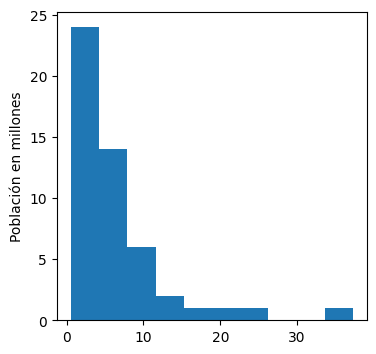

In [47]:
#Histograma de población por estados:
ax = (data.Population/1_000_000).plot.hist(figsize=(4,4))
ax.set_ylabel("Población en millones")

Text(0.5, 0, 'Tasa de asesinatos por 1000000 habitantes')

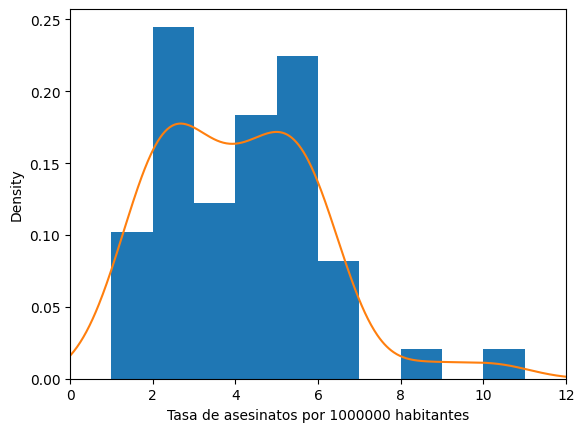

In [48]:
#Diagrama de dispersión y curva de densidad
ax=data["Murder.Rate"].plot.hist(density=True,xlim=[0,12],bins=range(1,12))
data["Murder.Rate"].plot.density(ax=ax)
ax.set_xlabel("Tasa de asesinatos por 1000000 habitantes")

#ACTIVIDAD

##1. Calcule las mismas métricas en su propio dataset.
##2. Responda las siguientes preguntas.

### Sobre Estimaciones de variabilidad
1.   Qué significa que la desviación estándar es casi dos veces mayor que la MAD?
Que la desviación estándar sea casi el doble que la Desviación Absoluta (MAD) significa que el conjunto de datos presenta valores atípicos extremos (outliers) o una fuerte asimetría. La desviación estándar calcula las distancias respecto a la media elevándolas al cuadrado, lo que magnifica drásticamente el impacto de las observaciones extremas e infla el resultado. En contraste, la MAD utiliza el valor absoluto de las diferencias, siendo una medida robusta que no se deja distorsionar por valores alejados. Esta discrepancia tan marcada indica que la variabilidad real de la mayoría de los datos es mucho menor de lo que sugiere la desviación estándar.

2. Cómo puedo mejorar esta situación?
Para mejorar esta situación, el primer paso es identificar y depurar los datos mediante un diagnóstico de valores atípicos para determinar si corresponden a errores de medición o digitación, los cuales deben corregirse o eliminarse, o si son datos reales legítimos. Si son valores reales pero extremos, se podría utilizar métricas robustas como reportar la mediana junto con la MAD o el IQR en lugar de la media y la desviación estándar o bien aplicar una transformación matemática a la variable (como la transformación logarítmica o de raíz cuadrada) para estabilizar la varianza, comprimir los valores altos y reducir la asimetría

3. Explique el resultado obtenido al calcular IQR
El resultado obtenido al calcular el Rango Intercuartílico representa la amplitud o dispersión del 50% central de los datos, descartando el 25% de los valores más bajos y el 25% de los más altos. Este indicador suministra la verdadera variabilidad de las observaciones "típicas" del estudio sin ser afectado por las colas de la distribución ni por los datos atípicos. Un IQR pequeño indica que la mitad central de los estados o individuos está muy concentrada alrededor de la mediana, mientras que un IQR grande refleja que incluso la parte central del grupo tiene una variación considerable.

### Sobre exploración en distribución de datos
1. Qué información nos suministra los percentiles de tasa de homicidios por estados?

Los percentiles indican la posición relativa de cada estado en comparación con el resto del país, ordenados de menor a mayor tasa de homicidios. En lugar de resumir todo en un solo número promedio, los percentiles dividen al total de estados para mostrar qué porcentaje de ellos se encuentra por debajo o por encima de cierto nivel de violencia. Por ejemplo, el percentil 25 fija el umbral del 25% de los estados más seguros, el percentil 50 (la mediana) marca el punto medio donde la mitad del país tiene mayor violencia y la otra mitad menor, y el percentil 75 o 90 identifica a los estados en situación más crítica. En resumen, sirven para saber qué tan grave es la situación de un estado respecto a los demás y cómo se distribuye realmente la inseguridad en el territorio sin que unos pocos valores extremos distorsionen la imagen general.

2. Explique con sus propias palabras qué información suministra el diagrama de caja con respecto a la tasa de homicidios por estado.
El diagrama de caja ofrece una fotografía visual de la distribución de la violencia en el país sin dejarse engañar por simples promedios. En una sola imagen nos suministra tres datos clave: primero, la mediana o la línea central, que marca la tasa de homicidios de un estado típico o representativo. Segundo, el tamaño de la caja, que encierra al 50% central de los estados; si la caja es corta, significa que la mayoría del país comparte niveles de homicidios muy similares, mientras que una caja ancha refleja gran desigualdad entre regiones. Y tercero, los puntos fuera de la caja (valores atípicos), que destacan de inmediato a aquellos estados que viven una situación de violencia o seguridad extremadamente alejada del patrón general.

3. Cómo podría agregarse los estados que se encuentran en cada uno de los intervalos? Si no sabe la respuesta, complete la tabla de forma manual y postee su respuesta. Interprete los resultados obtenidos.

4. Explique el resultado obtenido por el diagrama de dispersión.
El resultado muestra que la mayoría de los estados se concentran en un rango de 1 a 7 asesinatos por millón de habitantes, presentando una distribución bimodal con dos picos bien definidos uno entre 2.5 y 3, y otro cerca de 5 a 5.5; que reflejan dos grupos distintos de estados según su nivel de violencia; asimismo, la cola hacia la derecha, osea sesgo positivo, evidencia que existe un reducido número de estados con tasas de homicidio atípicamente elevadas (entre 8 y 11) que se alejan de la tendencia general del país.

##Nota:
El resultado de ambos ejercicios debe ser subido a GitHub
